In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Cargar los datos
df = pd.read_excel('Base_Migracion_2009-2026jun.xlsx')

In [7]:
print("--- VALORES FALTANTES ---")
print(df.isnull().sum())

print("\n--- VALORES DUPLICADOS ---")
print(f"Total de filas duplicadas: {df.duplicated().sum()}")

--- VALORES FALTANTES ---
Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
dtype: int64

--- VALORES DUPLICADOS ---
Total de filas duplicadas: 0


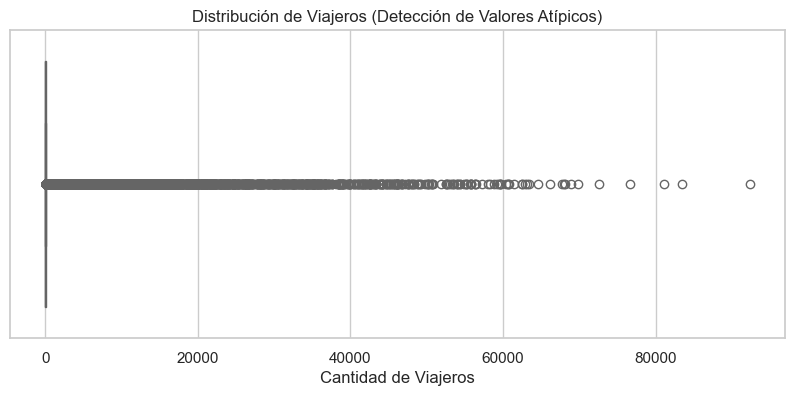

In [8]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Viajero'], color='coral')
plt.title('Distribución de Viajeros (Detección de Valores Atípicos)')
plt.xlabel('Cantidad de Viajeros')
plt.show()

In [9]:
print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
print(df.describe(include='all'))


--- ESTADÍSTICAS DESCRIPTIVAS ---
                  Año        Mes cod     Mes        Vía      Frontera  \
count   161036.000000  161036.000000  161036     161036        161036   
unique            NaN            NaN      12          3            22   
top               NaN            NaN     Ene  Terrestre  01 La Aurora   
freq              NaN            NaN   14726     125873         21424   
mean      2016.017543       6.416075     NaN        NaN           NaN   
std          4.552887       3.531936     NaN        NaN           NaN   
min       2009.000000       1.000000     NaN        NaN           NaN   
25%       2012.000000       3.000000     NaN        NaN           NaN   
50%       2016.000000       6.000000     NaN        NaN           NaN   
75%       2019.000000      10.000000     NaN        NaN           NaN   
max       2026.000000      12.000000     NaN        NaN           NaN   

             País  Región Región dos     Regiones OMT      MCEO  \
count      161036  16

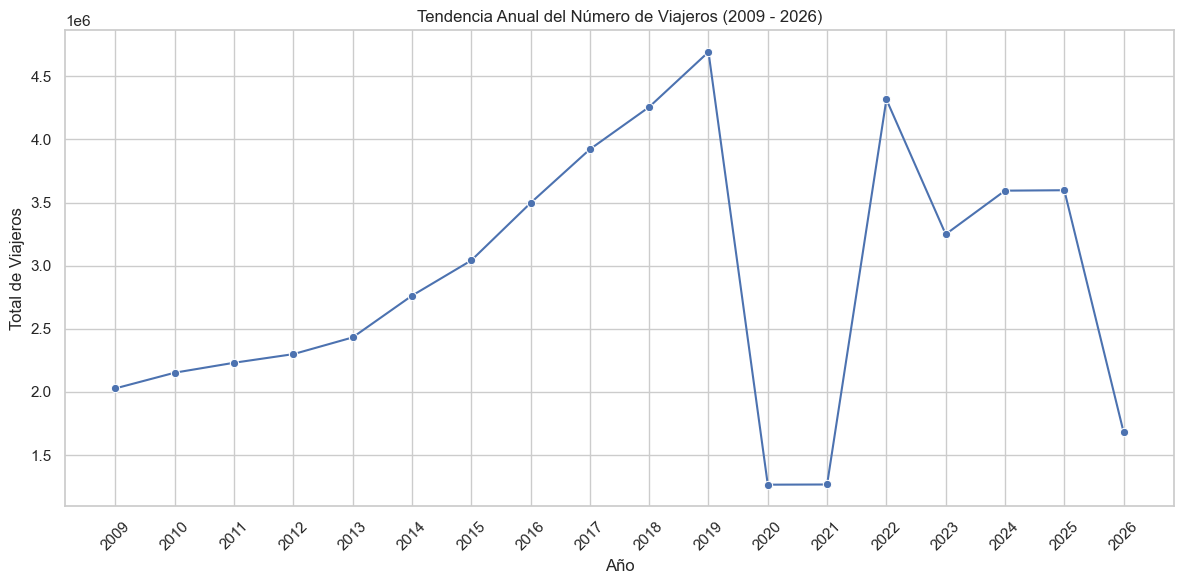

In [10]:
tendencia_anual = df.groupby('Año')['Viajero'].sum().reset_index()

plt.figure()
sns.lineplot(data=tendencia_anual, x='Año', y='Viajero', marker='o', color='b')
plt.title('Tendencia Anual del Número de Viajeros (2009 - 2026)')
plt.xlabel('Año')
plt.ylabel('Total de Viajeros')
plt.xticks(tendencia_anual['Año'].unique(), rotation=45)
plt.tight_layout()
plt.show()

C:\Users\dolan\AppData\Local\Temp\ipykernel_14252\1344887729.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_paises, x='Viajero', y='País', palette='viridis')


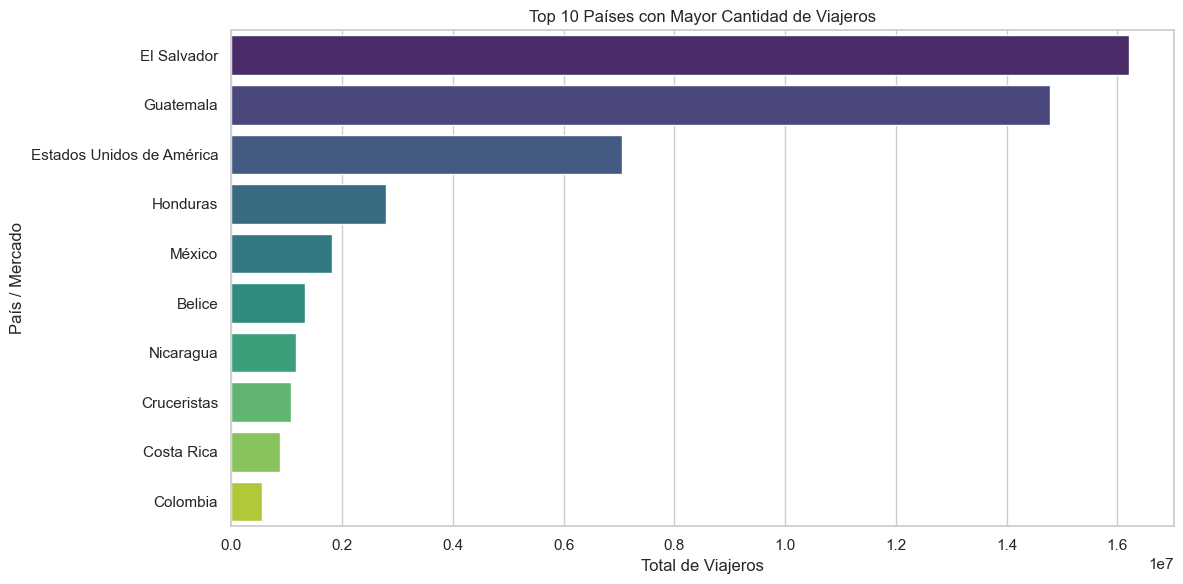

In [11]:
top_paises = df.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure()
sns.barplot(data=top_paises, x='Viajero', y='País', palette='viridis')
plt.title('Top 10 Países con Mayor Cantidad de Viajeros')
plt.xlabel('Total de Viajeros')
plt.ylabel('País / Mercado')
plt.tight_layout()
plt.show()

C:\Users\dolan\AppData\Local\Temp\ipykernel_14252\1009164120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_regiones, x='Viajero', y='Región', palette='magma')


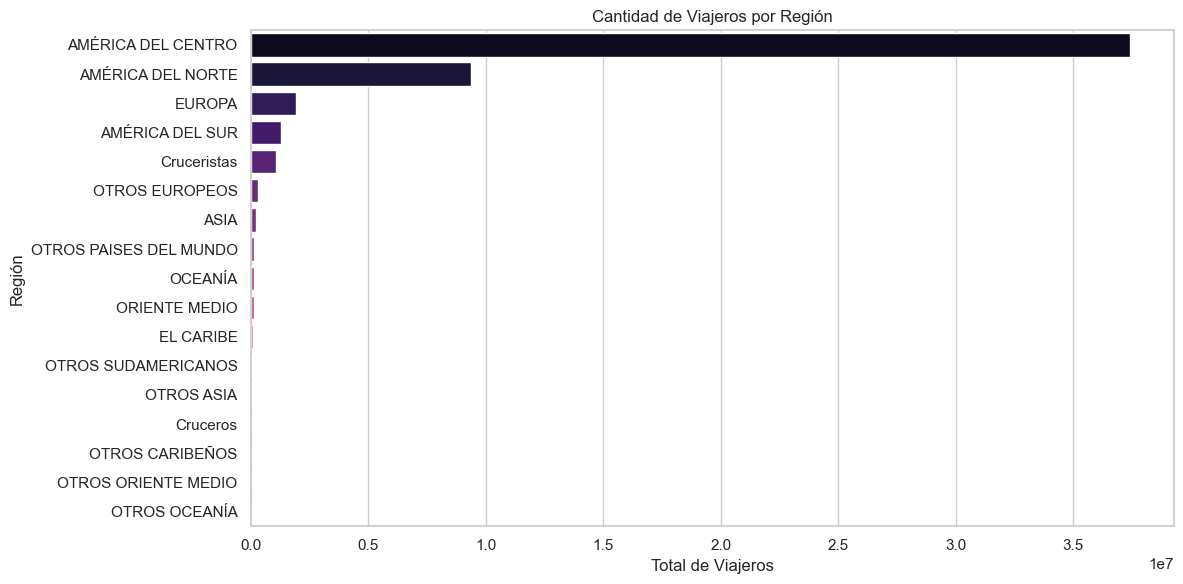

In [13]:
top_regiones = df.groupby('Región')['Viajero'].sum().sort_values(ascending=False).reset_index()

plt.figure()
sns.barplot(data=top_regiones, x='Viajero', y='Región', palette='magma')
plt.title('Cantidad de Viajeros por Región')
plt.xlabel('Total de Viajeros')
plt.ylabel('Región')
plt.tight_layout()
plt.show()

C:\Users\dolan\AppData\Local\Temp\ipykernel_14252\2230905737.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vias, x='Vía', y='Viajero', palette='Set2')


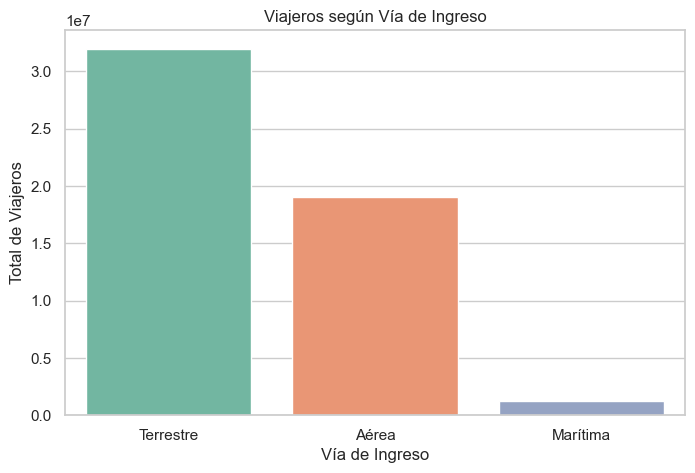

In [14]:
vias = df.groupby('Vía')['Viajero'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=vias, x='Vía', y='Viajero', palette='Set2')
plt.title('Viajeros según Vía de Ingreso')
plt.xlabel('Vía de Ingreso')
plt.ylabel('Total de Viajeros')
plt.show()

C:\Users\dolan\AppData\Local\Temp\ipykernel_14252\870184839.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_fronteras, x='Viajero', y='Frontera', palette='cubehelix')


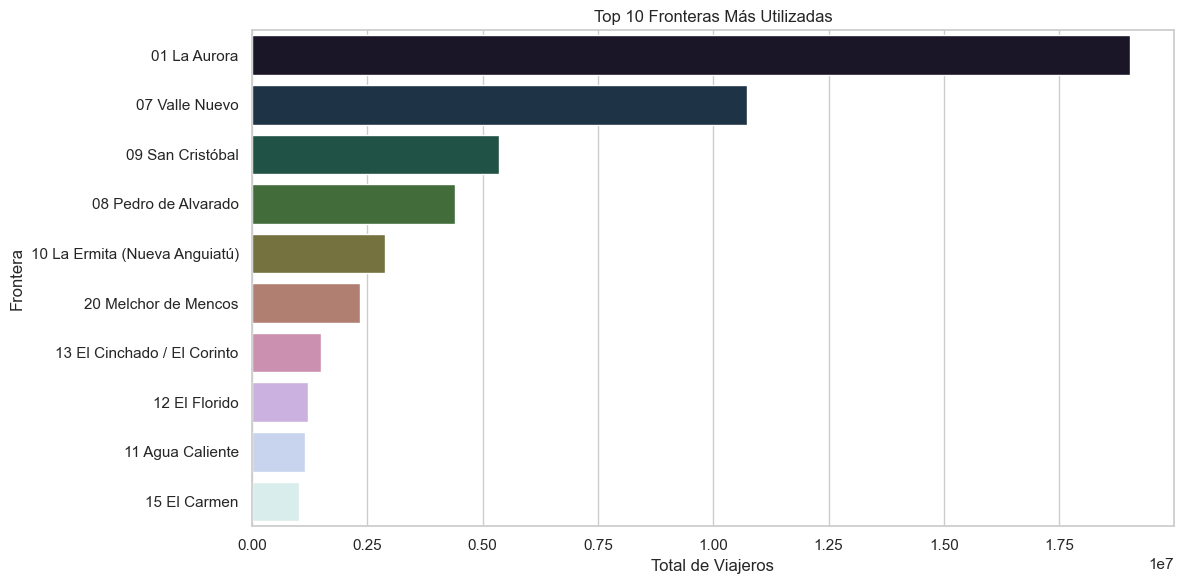

In [16]:
top_fronteras = df.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure()
sns.barplot(data=top_fronteras, x='Viajero', y='Frontera', palette='cubehelix')
plt.title('Top 10 Fronteras Más Utilizadas')
plt.xlabel('Total de Viajeros')
plt.ylabel('Frontera')
plt.tight_layout()
plt.show()